In [1]:
import numpy as np

import pandas as pd

In [2]:
df=pd.read_csv("/run/media/darshchouhan/New Volume/ML-Algorithm/projects/Sentiment_Analysis/IMDB Dataset.csv")

In [3]:
from  sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
encoder= LabelEncoder()

In [5]:
df['sentiment']=encoder.fit_transform(df['sentiment'])

In [6]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [7]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [8]:
import re
def clean_html(text):
  clean= re.compile('<.*?>')
  return re.sub(clean,'',text)


In [9]:
df['review']=df['review'].apply(clean_html)

In [10]:
def convert_lower(text):
  return  text.lower()

In [11]:
df['review']=df['review'].apply(convert_lower)

### Function for the removing special characters

In [12]:
def remove_special(text):
  x=''
  for i in text:
    if i.isalnum():
      x=x+i
    else:
      x=x+' '
  return x

In [13]:

import nltk

In [14]:
from nltk.corpus import stopwords

In [15]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/darshchouhan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))   # Create once

def remove_stopwords(text):
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

In [17]:
df['review']=df['review'].apply(remove_stopwords)

In [18]:
from nltk.stem.porter import PorterStemmer
ps= PorterStemmer()

In [19]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def stem_words(text):

  stemmed_words = [ps.stem(word) for word in text.split()]
  return " ".join(stemmed_words)


In [20]:
def stem_words(text):
    return " ".join(ps.stem(word) for word in text.split())

In [21]:
df

,review,sentiment
0,one reviewers mentioned watching 1 oz episode ...,1
1,wonderful little production. filming technique...,1
2,thought wonderful way spend time hot summer we...,1
3,basically there's family little boy (jake) thi...,0
4,"petter mattei's ""love time money"" visually stu...",1
...,...,...
49995,thought movie right good job. creative origina...,1
49996,"bad plot, bad dialogue, bad acting, idiotic di...",0
49997,catholic taught parochial elementary schools n...,0
49998,going disagree previous comment side maltin on...,0


In [22]:
df['review'] =  df['review'].apply(stem_words)

In [23]:
df['review']

0        one review mention watch 1 oz episod hooked. r...
1        wonder littl production. film techniqu unassum...
2        thought wonder way spend time hot summer weeke...
3        basic there' famili littl boy (jake) think the...
4        petter mattei' "love time money" visual stun f...
                               ...                        
49995    thought movi right good job. creativ origin fi...
49996    bad plot, bad dialogue, bad acting, idiot dire...
49997    cathol taught parochi elementari school nuns, ...
49998    go disagre previou comment side maltin one. se...
49999    one expect star trek movi high art, fan expect...
Name: review, Length: 50000, dtype: object

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df=2, sublinear_tf=True)   

In [25]:
df.shape

(50000, 2)

In [26]:
df['review'].shape

(50000,)

In [27]:
df['review']

0        one review mention watch 1 oz episod hooked. r...
1        wonder littl production. film techniqu unassum...
2        thought wonder way spend time hot summer weeke...
3        basic there' famili littl boy (jake) think the...
4        petter mattei' "love time money" visual stun f...
                               ...                        
49995    thought movi right good job. creativ origin fi...
49996    bad plot, bad dialogue, bad acting, idiot dire...
49997    cathol taught parochi elementari school nuns, ...
49998    go disagre previou comment side maltin one. se...
49999    one expect star trek movi high art, fan expect...
Name: review, Length: 50000, dtype: object

In [28]:
X = tfidf.fit_transform(df['review'])

In [29]:
y=df.iloc[:,-1]

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [31]:
type(X_train)

scipy.sparse._csr.csr_matrix

In [32]:
from sklearn.naive_bayes import BernoulliNB,MultinomialNB,GaussianNB
clf1 = GaussianNB()
clf2 = MultinomialNB(alpha=0.5)
clf3 =  BernoulliNB()

In [33]:
# clf1.fit(X_train.toarray(), y_train)
clf2.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.5
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[18843.,18657.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.7 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 56784)","[[ 9.82,20.87, 0.1 ,..., 0. , 0. , 0.67], [ 7.21,15.55, 0. ,..., 0.18, 0.39, 0.37]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 56784)","[[ -9.83, -9.1 ,-12.68,...,-12.86,-12.86,-12.01], [-10.11, -9.38,-12.85,...,-12.55,-12.27,-12.3 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,56784


In [34]:
y_pred2 = clf2.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
print(accuracy_score(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

0.8628
0.8757713543358233
[[5392  765]
 [ 950 5393]]


In [36]:
clf3.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[18843.,18657.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.69,-0.7 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 56784)","[[ 75.,206., 1.,..., 0., 0., 5.], [ 61.,162., 0.,..., 1., 2., 3.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 56784)","[[-5.51,-4.51,-9.15,...,-9.84,-9.84,-8.05], [-5.71,-4.74,-9.83,...,-9.14,-8.74,-8.45]]"


In [37]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
y_pred3 = clf3.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(precision_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))

0.85128
0.8760483059376049
[[5418  739]
 [1120 5223]]


### Testing the remaining models

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [39]:
lr = LogisticRegression()
rfc = RandomForestClassifier()
adc = AdaBoostClassifier()
bag = BaggingClassifier()
gr = GradientBoostingClassifier()

In [40]:
models = [lr,rfc,adc,bag,gr]

In [41]:
def model_training(model,X,y_train,X_test,y_test):
    model = model
    model.fit(X,y_train)
    pred = model.predict(X_test)
    print(model)
    print("Accuracy",accuracy_score(y_test,pred))
    print("precision",precision_score(y_test,pred))
    print("Confusion",confusion_matrix(y_test,pred))

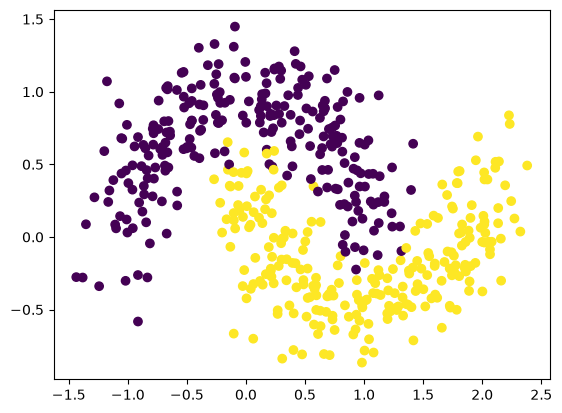

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y)